# Experiment 3

In [ ]:
import os, time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

#  save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/MSDS458_RA02_Experiments"
os.makedirs(base_dir, exist_ok=True)
print("Saving to:", base_dir)


Mounted at /content/drive
Saving to: /content/drive/MyDrive/MSDS458_RA02_Experiments


In [ ]:
base_dir = "/content"


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("train:", x_train.shape, y_train.shape)
print("test :", x_test.shape, y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
train: (50000, 32, 32, 3) (50000, 1)
test : (10000, 32, 32, 3) (10000, 1)


In [ ]:
x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, shuffle=True
)

x_train_norm = x_train_split / 255.0
x_valid_norm = x_valid_split / 255.0
x_test_norm  = x_test / 255.0

print("train:", x_train_norm.shape, y_train_split.shape)
print("valid:", x_valid_norm.shape, y_valid_split.shape)
print("test :", x_test_norm.shape, y_test.shape)


train: (45000, 32, 32, 3) (45000, 1)
valid: (5000, 32, 32, 3) (5000, 1)
test : (10000, 32, 32, 3) (10000, 1)


In [ ]:
def compile_train_model(model, exp_name,
                        x_train, y_train,
                        x_valid, y_valid,
                        optimizer='adam',
                        batch_size=64,
                        epochs=200,
                        patience=3,
                        save_dir=base_dir):

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    ckpt_path = os.path.join(save_dir, f"{exp_name}.keras")

    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, save_weights_only=False),
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=False)
    ]

    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    train_time = round(time.time() - t0, 2)
    print(f"Finished {exp_name} in {train_time}s")
    return history, train_time, ckpt_path


In [ ]:
tf.keras.backend.clear_session()

exp_name = "Exp3_CNN_2block_no_reg"

cnn2 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name=exp_name)

cnn2.summary()


Model: "Exp3_CNN_2block_no_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history3, time3, path3 = compile_train_model(
    cnn2, exp_name,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=3
)


Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 101ms/step - accuracy: 0.3754 - loss: 1.7183 - val_accuracy: 0.5866 - val_loss: 1.1836
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.5973 - loss: 1.1512 - val_accuracy: 0.6342 - val_loss: 1.0346
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 102ms/step - accuracy: 0.6628 - loss: 0.9710 - val_accuracy: 0.6482 - val_loss: 1.0106
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 98ms/step - accuracy: 0.6991 - loss: 0.8634 - val_accuracy: 0.6846 - val_loss: 0.8973
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.7296 - loss: 0.7857 - val_accuracy: 0.6862 - val_loss: 0.9173
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.7463 - loss: 0.7259 - val_accuracy: 0.6826 - val_loss: 0.9192
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 0.7721 - loss: 0.6555 - val_accuracy: 0.6888 - val_loss: 0.9074
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.7964 - loss:

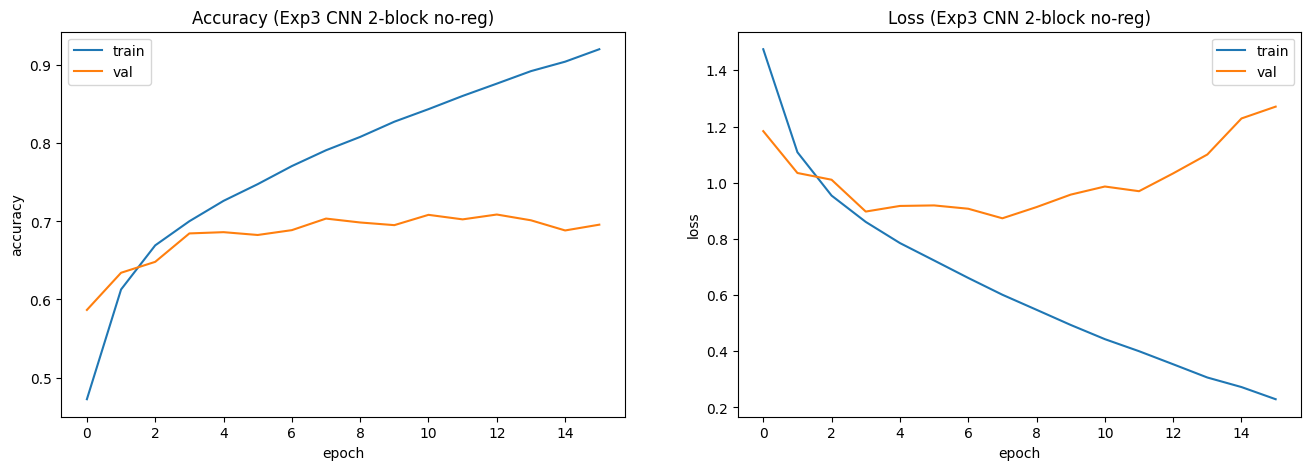

In [ ]:
def plot_history(history, title=""):
    df = pd.DataFrame(history.history)
    plt.figure(figsize=(16,5))

    plt.subplot(1,2,1)
    plt.plot(df["accuracy"]); plt.plot(df["val_accuracy"])
    plt.title(f"Accuracy {title}")
    plt.xlabel("epoch"); plt.ylabel("accuracy")
    plt.legend(["train","val"])

    plt.subplot(1,2,2)
    plt.plot(df["loss"]); plt.plot(df["val_loss"])
    plt.title(f"Loss {title}")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(["train","val"])

    plt.show()

plot_history(history3, title="(Exp3 CNN 2-block no-reg)")


Test loss: 0.8873 | Test acc: 0.7057


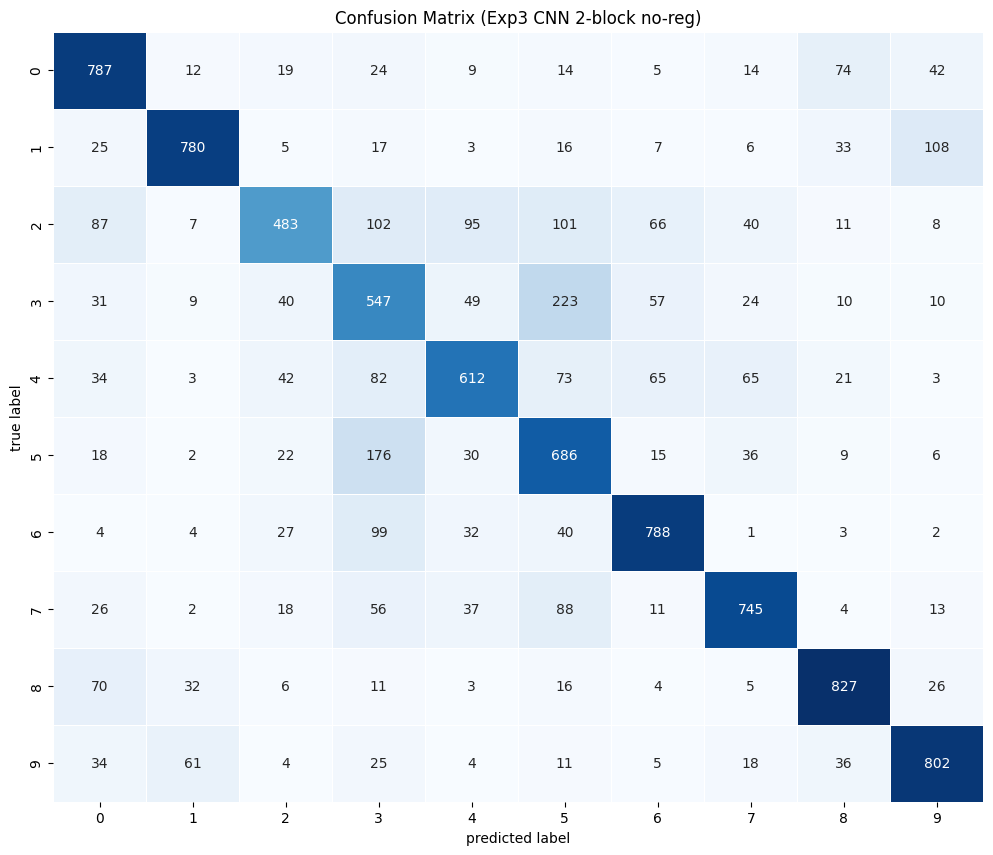

              precision    recall  f1-score   support

           0       0.71      0.79      0.74      1000
           1       0.86      0.78      0.82      1000
           2       0.73      0.48      0.58      1000
           3       0.48      0.55      0.51      1000
           4       0.70      0.61      0.65      1000
           5       0.54      0.69      0.60      1000
           6       0.77      0.79      0.78      1000
           7       0.78      0.74      0.76      1000
           8       0.80      0.83      0.82      1000
           9       0.79      0.80      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000

Accuracy Score: 0.7057


In [ ]:
model3 = tf.keras.models.load_model(path3)

test_loss3, test_acc3 = model3.evaluate(x_test_norm, y_test, verbose=0)
print(f"Test loss: {test_loss3:.4f} | Test acc: {test_acc3:.4f}")

pred3 = np.argmax(model3.predict(x_test_norm, verbose=0), axis=1)
y_test_flat = y_test.reshape(-1)

cm3 = confusion_matrix(y_test_flat, pred3)

plt.figure(figsize=(12,10))
sns.heatmap(cm3, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5, linecolor="white")
plt.xlabel("predicted label"); plt.ylabel("true label")
plt.title("Confusion Matrix (Exp3 CNN 2-block no-reg)")
plt.show()

print(classification_report(y_test_flat, pred3))
print("Accuracy Score:", accuracy_score(y_test_flat, pred3))


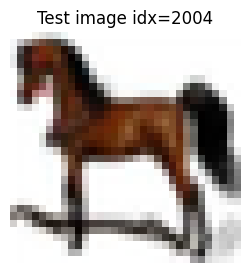

MaxPool layers: ['max_pooling2d', 'max_pooling2d_1']
[(1, 16, 16, 32), (1, 8, 8, 64)]


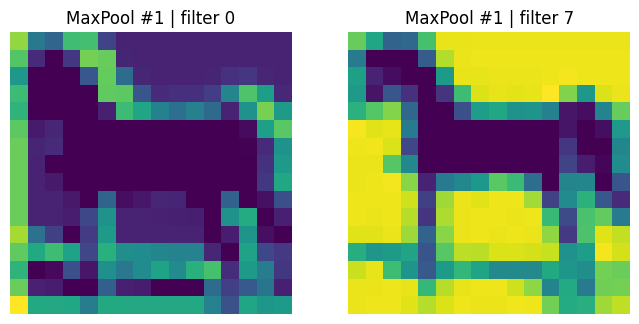

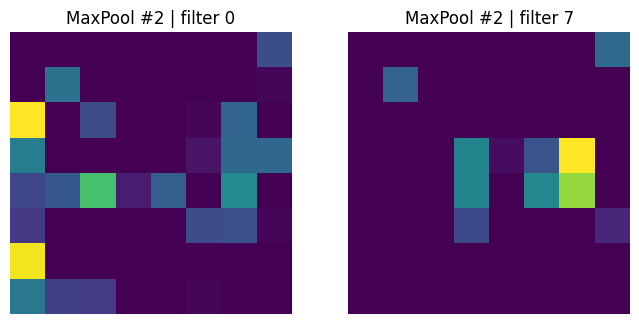

In [ ]:
# pick a test image
img_index = 2004
img = x_test[img_index]
img_tensor = np.expand_dims(img/255.0, axis=0)

plt.figure(figsize=(3,3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Test image idx={img_index}")
plt.show()

# build activation model for 2 maxpool layers
maxpool_layers = [layer for layer in model3.layers if isinstance(layer, MaxPooling2D)]
print("MaxPool layers:", [l.name for l in maxpool_layers])

activation_model = tf.keras.Model(
    inputs=model3.inputs,  # IMPORTANT: use inputs (not input)
    outputs=[l.output for l in maxpool_layers]
)

pool_acts = activation_model.predict(img_tensor, verbose=0)
print([a.shape for a in pool_acts])

def show_two_filters(act, title, filter_ids=(0, 7)):
    f1, f2 = filter_ids
    C = act.shape[-1]
    f1 = min(f1, C-1); f2 = min(f2, C-1)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(act[0,:,:,f1], cmap="viridis")
    plt.title(f"{title} | filter {f1}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(act[0,:,:,f2], cmap="viridis")
    plt.title(f"{title} | filter {f2}")
    plt.axis("off")
    plt.show()

show_two_filters(pool_acts[0], "MaxPool #1", (0, 7))
show_two_filters(pool_acts[1], "MaxPool #2", (0, 7))


In [ ]:
row3 = {
    "experiment": exp_name,
    "params": model3.count_params(),
    "train_loss": history3.history["loss"][-1],
    "train_acc": history3.history["accuracy"][-1],
    "val_loss": history3.history["val_loss"][-1],
    "val_acc": history3.history["val_accuracy"][-1],
    "test_loss": test_loss3,
    "test_acc": test_acc3,
    "train_time_sec": time3,
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history3.history["loss"])
}

row3


{'experiment': 'Exp3_CNN_2block_no_reg',
 'params': 545098,
 'train_loss': 0.22925236821174622,
 'train_acc': 0.9205111265182495,
 'val_loss': 1.270857810974121,
 'val_acc': 0.6958000063896179,
 'test_loss': 0.887322187423706,
 'test_acc': 0.7056999802589417,
 'train_time_sec': 1201.5,
 'optimizer': 'adam',
 'batch_size': 64,
 'epochs_ran': 16}

In [ ]:
results_df = pd.DataFrame(columns=[
    "experiment","params",
    "train_loss","train_acc",
    "val_loss","val_acc",
    "test_loss","test_acc",
    "train_time_sec",
    "optimizer","batch_size","epochs_ran"
])

results_df



,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran


In [ ]:
results_df = pd.concat([results_df, pd.DataFrame([row3])], ignore_index=True)
results_df


/tmp/ipython-input-569589177.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([row3])], ignore_index=True)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.5,adam,64,16


/tmp/ipython-input-1273625811.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y[j])])


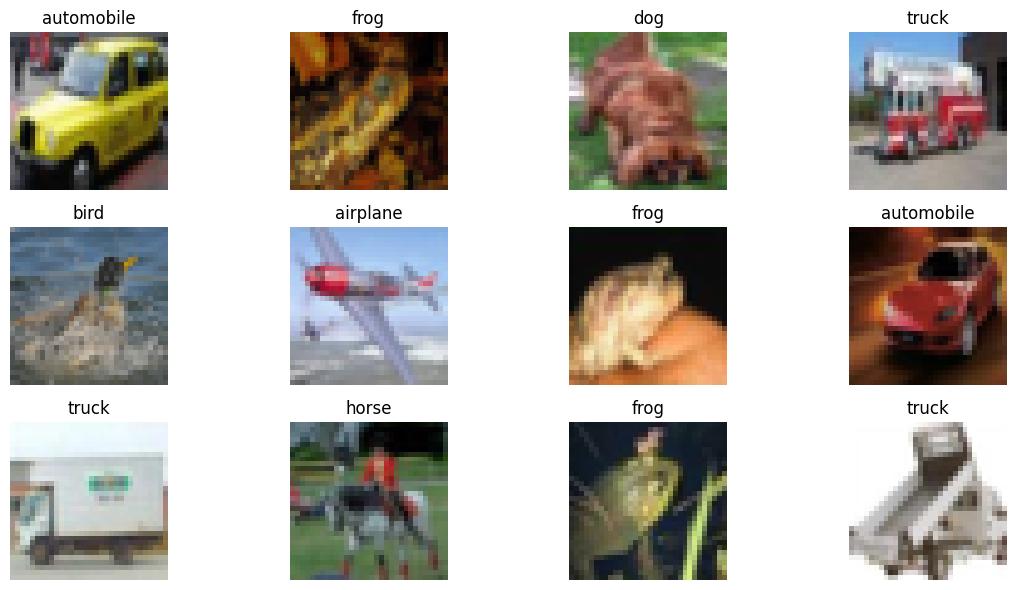

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

def show_random_images(x, y, n=12):
    idx = np.random.choice(len(x), n, replace=False)
    plt.figure(figsize=(12,6))

    for i, j in enumerate(idx):
        plt.subplot(3, 4, i+1)
        plt.imshow(x[j])
        plt.title(class_names[int(y[j])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(x_test, y_test, n=12)


/tmp/ipython-input-2116071941.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Index {i} | Label: {class_names[int(y_test[i])]}")


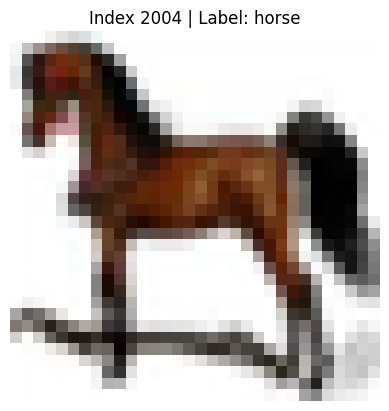

In [ ]:
i = 2004
plt.imshow(x_test[i])
plt.title(f"Index {i} | Label: {class_names[int(y_test[i])]}")
plt.axis("off")
plt.show()


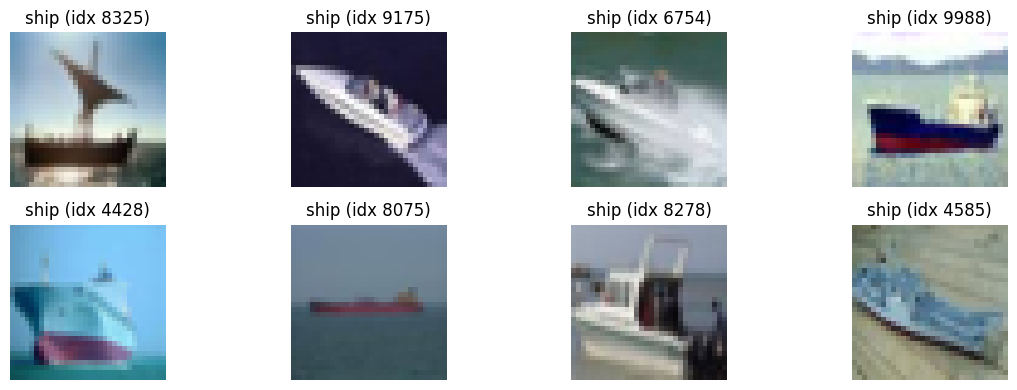

In [ ]:
def show_images_from_class(class_id, n=8):
    idx = np.where(y_test.reshape(-1) == class_id)[0]
    chosen = np.random.choice(idx, n, replace=False)

    plt.figure(figsize=(12,4))
    for k, j in enumerate(chosen):
        plt.subplot(2,4,k+1)
        plt.imshow(x_test[j])
        plt.title(f"{class_names[class_id]} (idx {j})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Ships = class 8
show_images_from_class(8, n=8)


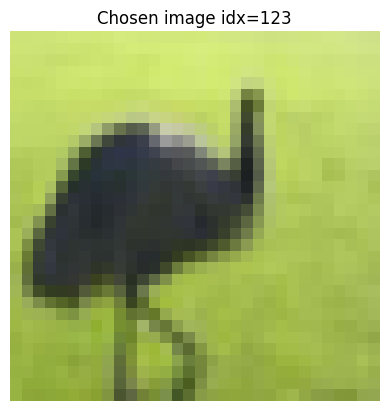

In [ ]:
img_index = 123
img = x_test[img_index]
img_tensor = np.expand_dims(img/255.0, axis=0)

plt.imshow(img)
plt.title(f"Chosen image idx={img_index}")
plt.axis("off")
plt.show()


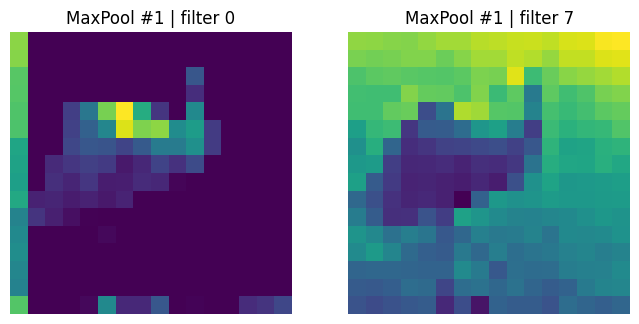

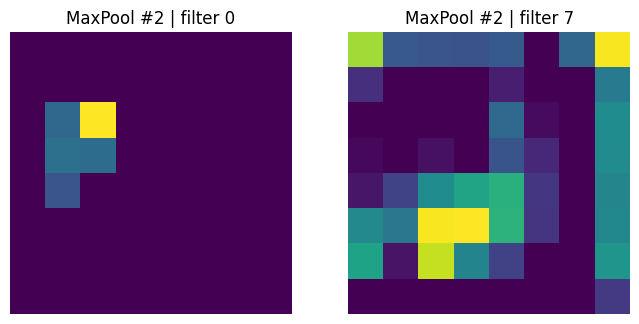

In [ ]:
maxpool_layers = [layer for layer in model3.layers if isinstance(layer, MaxPooling2D)]

activation_model = tf.keras.Model(
    inputs=model3.inputs,
    outputs=[l.output for l in maxpool_layers]
)

pool_acts = activation_model.predict(img_tensor, verbose=0)

show_two_filters(pool_acts[0], "MaxPool #1", (0,7))
show_two_filters(pool_acts[1], "MaxPool #2", (0,7))


# Experiment 4

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
exp_name4 = "Exp4_CNN_3block_no_reg"

cnn3 = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name=exp_name4)

cnn3.summary()

Model: "Exp4_CNN_3block_no_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history4, time4, path4 = compile_train_model(
    cnn3, exp_name4,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=3
)

print(f"Finished {exp_name4} in {time4:.2f}s")

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 138ms/step - accuracy: 0.3788 - loss: 1.7001 - val_accuracy: 0.5668 - val_loss: 1.1840
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6191 - loss: 1.0750 - val_accuracy: 0.6528 - val_loss: 0.9677
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - accuracy: 0.6960 - loss: 0.8634 - val_accuracy: 0.6978 - val_loss: 0.8761
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 131ms/step - accuracy: 0.7447 - loss: 0.7352 - val_accuracy: 0.7112 - val_loss: 0.8325
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.7766 - loss: 0.6462 - val_accuracy: 0.7068 - val_loss: 0.8419
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 133ms/step - accuracy: 0.8061 - loss: 0.5577 - val_accuracy: 0.7332 - val_loss: 0.7699
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - accuracy: 0.8305 - loss: 0.4933 - val_accuracy: 0.7490 - val_loss: 0.7632
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.856

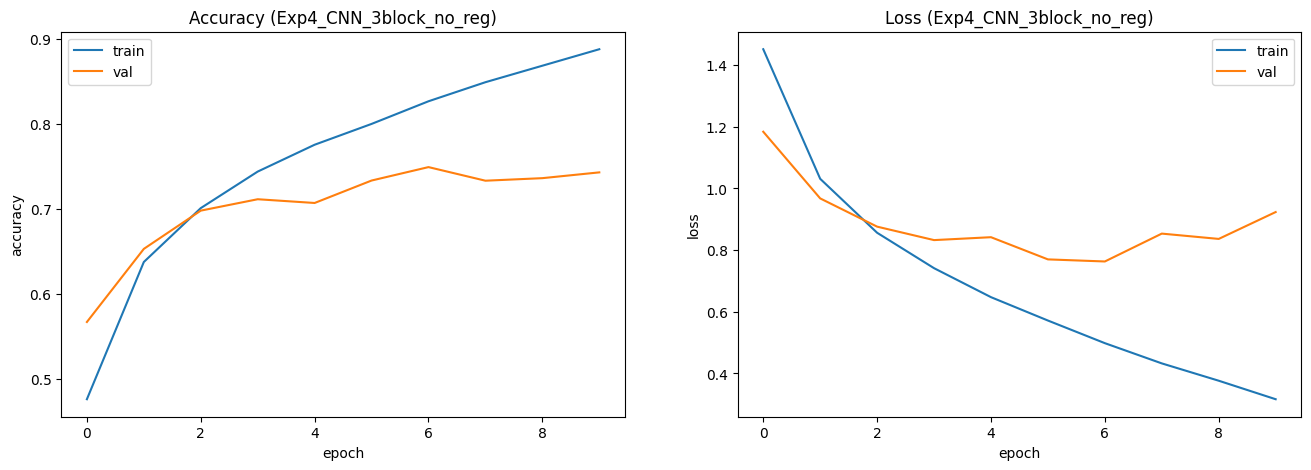

In [ ]:
plot_history(history4, title=f"({exp_name4})")

Test loss: 0.7945 | Test acc: 0.7432


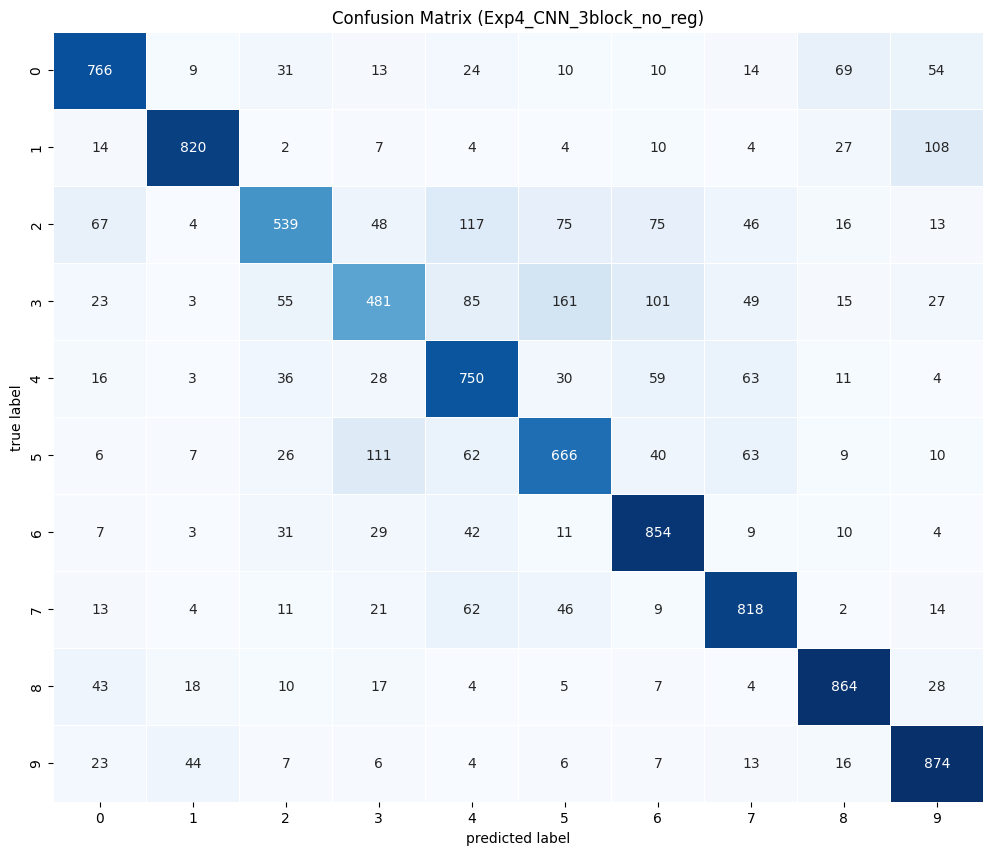

              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1000
           1       0.90      0.82      0.86      1000
           2       0.72      0.54      0.62      1000
           3       0.63      0.48      0.55      1000
           4       0.65      0.75      0.70      1000
           5       0.66      0.67      0.66      1000
           6       0.73      0.85      0.79      1000
           7       0.76      0.82      0.79      1000
           8       0.83      0.86      0.85      1000
           9       0.77      0.87      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000

Accuracy Score: 0.7432


In [ ]:
model4 = tf.keras.models.load_model(path4)

test_loss4, test_acc4 = model4.evaluate(x_test_norm, y_test, verbose=0)
print(f"Test loss: {test_loss4:.4f} | Test acc: {test_acc4:.4f}")

pred4 = np.argmax(model4.predict(x_test_norm, verbose=0), axis=1)
y_test_flat = y_test.reshape(-1)

cm4 = confusion_matrix(y_test_flat, pred4)

plt.figure(figsize=(12,10))
sns.heatmap(cm4, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5, linecolor="white")
plt.xlabel("predicted label"); plt.ylabel("true label")
plt.title(f"Confusion Matrix ({exp_name4})")
plt.show()

print(classification_report(y_test_flat, pred4))
print("Accuracy Score:", accuracy_score(y_test_flat, pred4))

In [ ]:
def show_random_images(x, y, n=12):
    idx = np.random.choice(len(x), n, replace=False)
    plt.figure(figsize=(12,6))
    for i, j in enumerate(idx):
        plt.subplot(3, 4, i+1)
        plt.imshow(x[j])
        plt.title(class_names[int(y[j])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_images_from_class(class_id, n=8):
    idx = np.where(y.reshape(-1) == class_id)[0]
    chosen = np.random.choice(idx, n, replace=False)
    plt.figure(figsize=(12,4))
    for k, j in enumerate(chosen):
        plt.subplot(2,4,k+1)
        plt.imshow(x[j])
        plt.title(f"{class_names[class_id]} (idx {j})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-471176824.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y[j])])


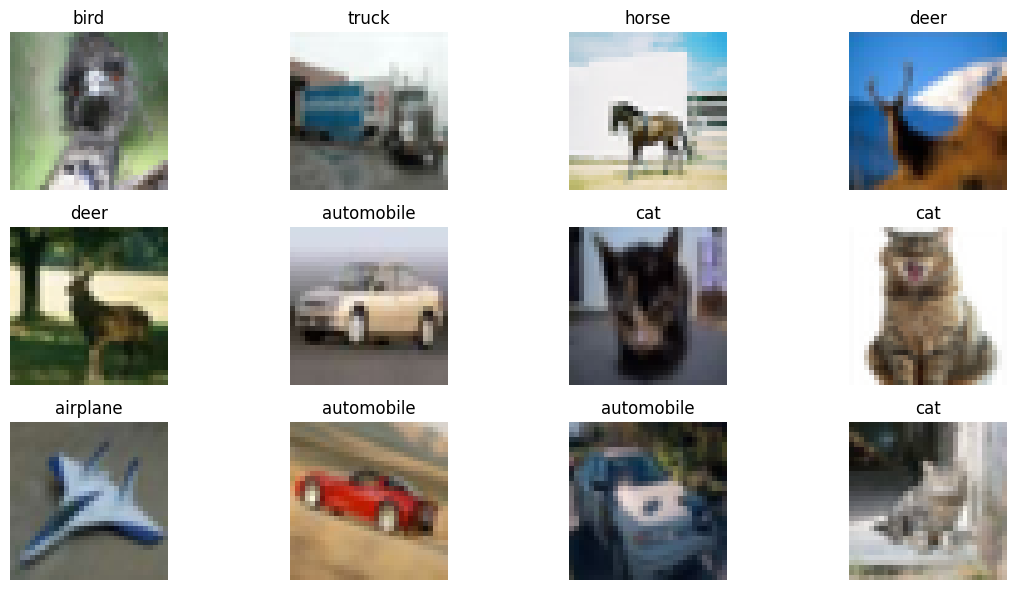

In [ ]:
show_random_images(x_test, y_test, n=12)

In [ ]:
img_index = np.random.randint(0, len(x_test))
img = x_test[img_index]
img_tensor = np.expand_dims(img/255.0, axis=0)

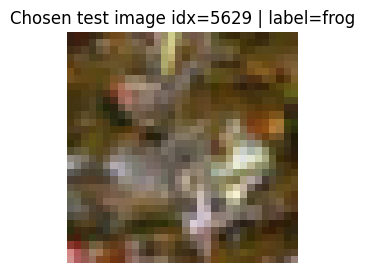

In [ ]:
plt.figure(figsize=(3,3))
plt.imshow(img)
plt.axis("off")
plt.title(f"Chosen test image idx={img_index} | label={class_names[int(y_test_flat[img_index])]}")
plt.show()

In [ ]:
maxpool_layers = [layer for layer in model4.layers if isinstance(layer, MaxPooling2D)]
print("MaxPool layers:", [l.name for l in maxpool_layers])

MaxPool layers: ['max_pooling2d_2', 'max_pooling2d_3', 'max_pooling2d_4']


In [ ]:
activation_model = tf.keras.Model(
    inputs=model4.inputs,
    outputs=[l.output for l in maxpool_layers]
)

In [ ]:
pool_acts = activation_model.predict(img_tensor, verbose=0)
print("Activation shapes:", [a.shape for a in pool_acts])

Activation shapes: [(1, 16, 16, 32), (1, 8, 8, 64), (1, 4, 4, 128)]


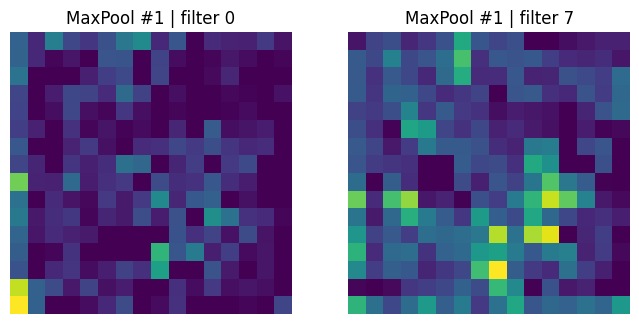

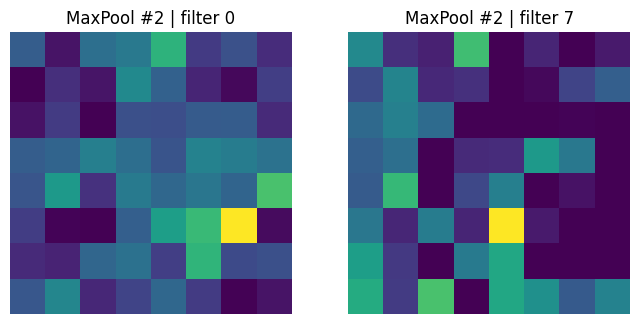

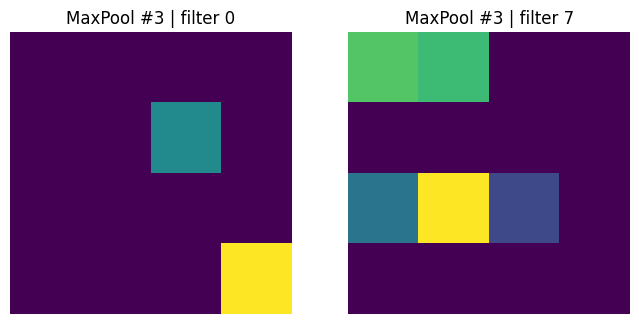

In [ ]:
show_two_filters(pool_acts[0], "MaxPool #1", (0,7))
show_two_filters(pool_acts[1], "MaxPool #2", (0,7))
show_two_filters(pool_acts[2], "MaxPool #3", (0,7))

In [ ]:
row4 = {
    "experiment": exp_name4,
    "params": model4.count_params(),
    "train_loss": history4.history["loss"][-1],
    "train_acc": history4.history["accuracy"][-1],
    "val_loss": history4.history["val_loss"][-1],
    "val_acc": history4.history["val_accuracy"][-1],
    "test_loss": test_loss4,
    "test_acc": test_acc4,
    "train_time_sec": time4,
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history4.history["loss"])
}

In [ ]:
if "results_df" not in globals():
    results_df = pd.DataFrame(columns=[
        "experiment","params",
        "train_loss","train_acc",
        "val_loss","val_acc",
        "test_loss","test_acc",
        "train_time_sec",
        "optimizer","batch_size","epochs_ran"
    ])

results_df.loc[len(results_df)] = row4
results_df

,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.50,adam,64,16
1,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.50,adam,64,16
2,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.50,adam,64,16
3,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.50,adam,64,16
4,Exp4_CNN_3block_no_reg,356810,0.316399,0.887667,0.923465,0.7428,0.794473,0.7432,1142.61,adam,64,10


# Experiment 5

In [ ]:
import time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [ ]:
def compile_train_model(model, exp_name,
                        x_train, y_train,
                        x_valid, y_valid,
                        optimizer='adam',
                        batch_size=64,
                        epochs=200,
                        patience=3):
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    ckpt_path = f"{exp_name}.keras"
    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, save_weights_only=False),
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=False)
    ]

    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - t0
    return history, train_time, ckpt_path


def plot_history(history, title=""):
    df = pd.DataFrame(history.history)
    plt.figure(figsize=(16,5))

    plt.subplot(1,2,1)
    plt.plot(df["accuracy"]); plt.plot(df["val_accuracy"])
    plt.title(f"Accuracy {title}")
    plt.xlabel("epoch"); plt.ylabel("accuracy")
    plt.legend(["train","val"])

    plt.subplot(1,2,2)
    plt.plot(df["loss"]); plt.plot(df["val_loss"])
    plt.title(f"Loss {title}")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(["train","val"])

    plt.show()


In [ ]:
tf.keras.backend.clear_session()

exp_name = "Exp5_DNN_2hidden_dropout"

dnn2_dropout = Sequential([
    Input(shape=(32,32,3)),
    Flatten(),

    Dense(384, activation='relu'),
    Dropout(0.3),

    Dense(192, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
], name=exp_name)

dnn2_dropout.summary()


Model: "Exp5_DNN_2hidden_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │     1,180,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,255,882 (4.79 MB)

 Trainable params: 1,255,882 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2112 - loss: 2.1756 - val_accuracy: 0.3044 - val_loss: 1.9177
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.2853 - loss: 1.9327 - val_accuracy: 0.3500 - val_loss: 1.8305
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3076 - loss: 1.8904 - val_accuracy: 0.3504 - val_loss: 1.8200
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.3231 - loss: 1.8573 - val_accuracy: 0.3704 - val_loss: 1.7719
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3319 - loss: 1.8381 - val_accuracy: 0.3628 - val_loss: 1.7777
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3337 - loss: 1.8266 - val_accuracy: 0.3842 - val_loss: 1.7667
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3404 - loss: 1.8143 - val_accuracy: 0.3640 - val_loss: 1.7752
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3532 - loss: 1

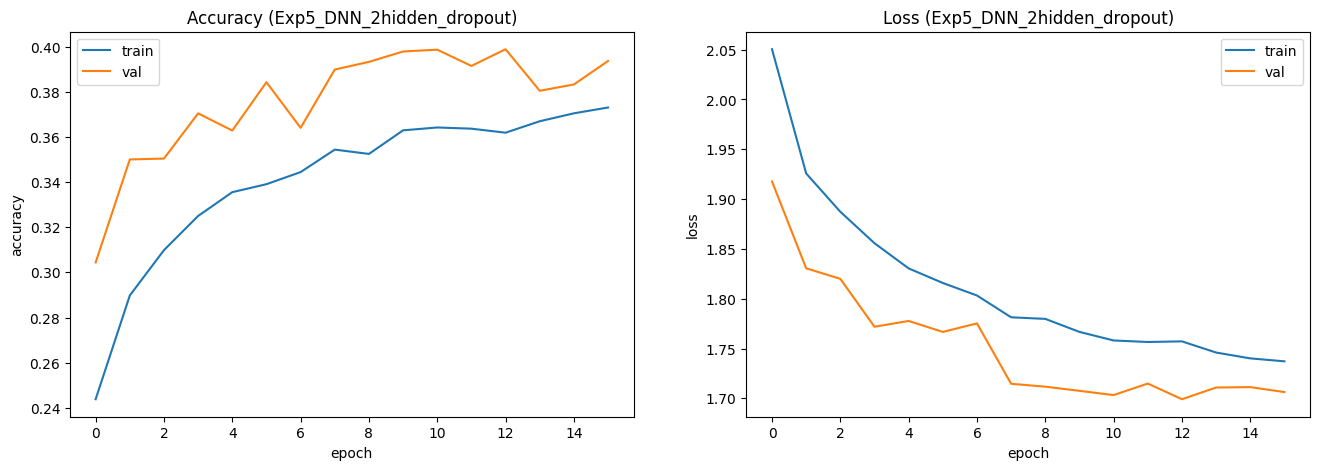

In [ ]:
history5, time5, path5 = compile_train_model(
    dnn2_dropout, exp_name,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=3
)

print(f"Finished {exp_name} in {time5:.2f}s")
plot_history(history5, title=f"({exp_name})")


Test loss: 1.6845 | Test acc: 0.4053


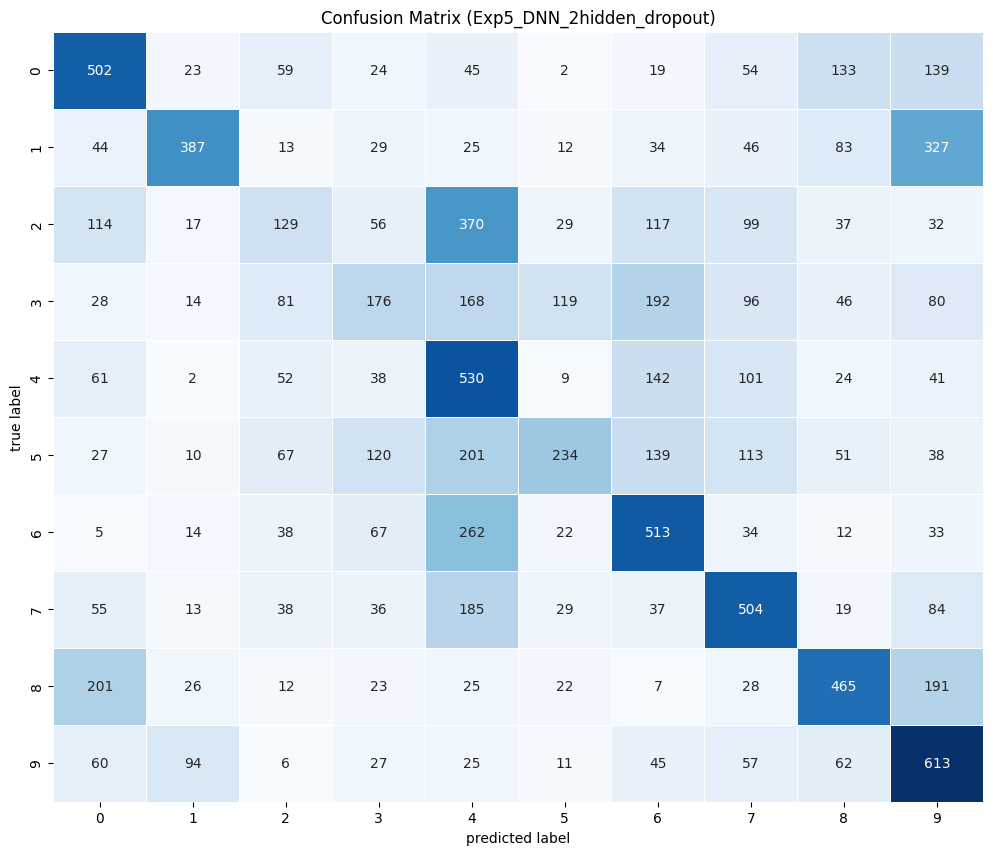

              precision    recall  f1-score   support

           0       0.46      0.50      0.48      1000
           1       0.65      0.39      0.48      1000
           2       0.26      0.13      0.17      1000
           3       0.30      0.18      0.22      1000
           4       0.29      0.53      0.37      1000
           5       0.48      0.23      0.31      1000
           6       0.41      0.51      0.46      1000
           7       0.45      0.50      0.47      1000
           8       0.50      0.47      0.48      1000
           9       0.39      0.61      0.48      1000

    accuracy                           0.41     10000
   macro avg       0.42      0.41      0.39     10000
weighted avg       0.42      0.41      0.39     10000

Accuracy Score: 0.4053


In [ ]:
model5 = tf.keras.models.load_model(path5)

test_loss5, test_acc5 = model5.evaluate(x_test_norm, y_test, verbose=0)
print(f"Test loss: {test_loss5:.4f} | Test acc: {test_acc5:.4f}")

pred5 = np.argmax(model5.predict(x_test_norm, verbose=0), axis=1)
y_test_flat = y_test.reshape(-1)

cm5 = confusion_matrix(y_test_flat, pred5)

plt.figure(figsize=(12,10))
sns.heatmap(cm5, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5, linecolor="white")
plt.xlabel("predicted label"); plt.ylabel("true label")
plt.title(f"Confusion Matrix ({exp_name})")
plt.show()

print(classification_report(y_test_flat, pred5))
print("Accuracy Score:", accuracy_score(y_test_flat, pred5))


In [ ]:
if "results_df" not in globals():
    results_df = pd.DataFrame(columns=[
        "experiment","params",
        "train_loss","train_acc",
        "val_loss","val_acc",
        "test_loss","test_acc",
        "train_time_sec",
        "optimizer","batch_size","epochs_ran"
    ])

row5 = {
    "experiment": exp_name,
    "params": model5.count_params(),
    "train_loss": history5.history["loss"][-1],
    "train_acc": history5.history["accuracy"][-1],
    "val_loss": history5.history["val_loss"][-1],
    "val_acc": history5.history["val_accuracy"][-1],
    "test_loss": test_loss5,
    "test_acc": test_acc5,
    "train_time_sec": time5,
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history5.history["loss"])
}

results_df.loc[len(results_df)] = row5
results_df


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.500000,adam,64,16
1,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.500000,adam,64,16
2,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.500000,adam,64,16
3,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.500000,adam,64,16
4,Exp4_CNN_3block_no_reg,356810,0.316399,0.887667,0.923465,0.7428,0.794473,0.7432,1142.610000,adam,64,10
5,Exp5_DNN_2hidden_dropout,1255882,1.737181,0.373000,1.706320,0.3936,1.684457,0.4053,256.202585,adam,64,16


In [ ]:
results_df = results_df.drop_duplicates(subset=["experiment"], keep="last").reset_index(drop=True)
results_df


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp3_CNN_2block_no_reg,545098,0.229252,0.920511,1.270858,0.6958,0.887322,0.7057,1201.500000,adam,64,16
1,Exp4_CNN_3block_no_reg,356810,0.316399,0.887667,0.923465,0.7428,0.794473,0.7432,1142.610000,adam,64,10
2,Exp5_DNN_2hidden_dropout,1255882,1.737181,0.373000,1.706320,0.3936,1.684457,0.4053,256.202585,adam,64,16


In [ ]:
preds = model5.predict(x_test_norm)

df = pd.DataFrame(preds[:10], columns=class_names)
df.style.format("{:.2%}").background_gradient(cmap="Blues")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,9.52%,3.46%,14.43%,15.38%,10.93%,14.90%,12.76%,4.44%,11.24%,2.95%
1,8.97%,22.71%,0.33%,0.38%,0.37%,0.10%,0.08%,0.46%,21.82%,44.78%
2,26.58%,12.07%,4.89%,1.67%,1.77%,1.11%,0.32%,1.67%,35.18%,14.74%
3,27.96%,7.53%,13.88%,2.25%,6.73%,2.08%,0.56%,4.45%,23.54%,11.02%
4,1.19%,0.33%,19.47%,5.15%,38.76%,7.20%,18.59%,8.87%,0.19%,0.25%
5,1.91%,2.85%,10.87%,17.21%,15.09%,10.83%,31.31%,6.43%,0.62%,2.87%
6,1.93%,1.24%,6.48%,32.74%,4.77%,33.49%,9.96%,6.86%,1.38%,1.15%
7,2.21%,0.96%,20.54%,6.27%,29.97%,6.44%,25.87%,6.83%,0.31%,0.61%
8,11.08%,3.35%,19.20%,11.94%,15.51%,11.27%,5.27%,13.32%,5.79%,3.29%
9,12.40%,30.20%,2.86%,1.91%,1.85%,0.78%,0.52%,1.36%,20.56%,27.56%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


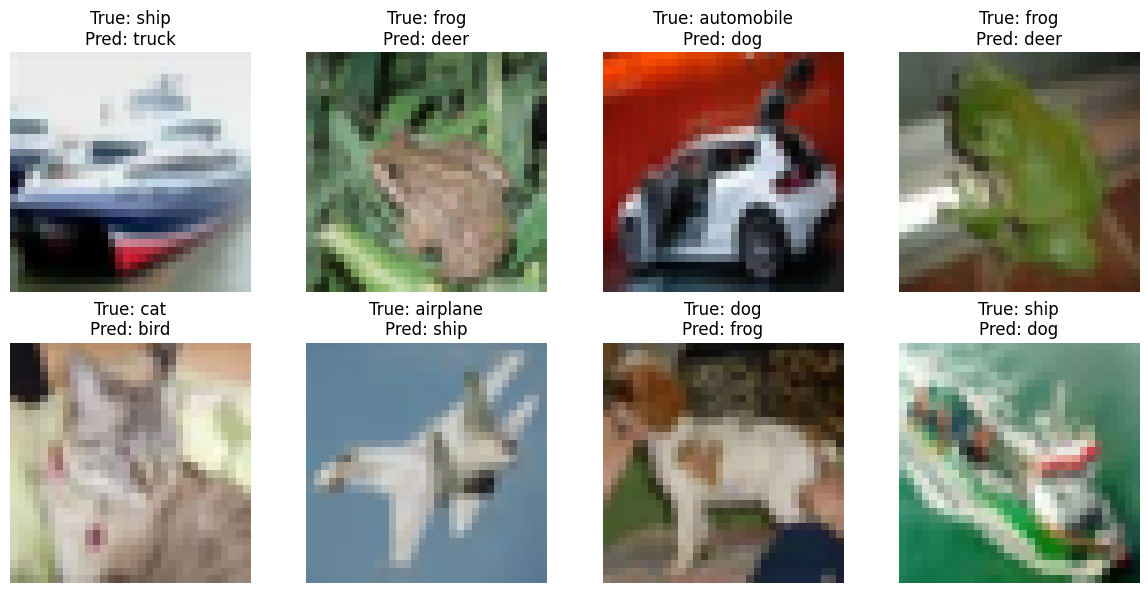

In [ ]:
y_pred = np.argmax(model5.predict(x_test_norm), axis=1)

wrong = np.where(y_pred != y_test.reshape(-1))[0]

plt.figure(figsize=(12,6))
for i, idx in enumerate(wrong[:8]):
    plt.subplot(2,4,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_test[idx][0]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
